# Project Title

Country Development Analysis using Hierarchical Clustering

# Project Objective

Build a machine learning model to group countries based on their socioeconomic and health indicators, helping identify countries with similar development levels.

# Real-World Problem

Governments and international organizations need to identify groups of countries that require similar development policies.

Instead of manually analyzing hundreds of countries, Hierarchical Clustering can automatically discover natural groups.

# Examples:

Developing Countries
Emerging Economies
Highly Developed Countries
Countries needing humanitarian aid

## Step1 Load Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## step 2 Load Dataset

In [17]:
df = pd.read_csv('Country-data.csv')

In [18]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## step3 Data Exploration 

In [19]:
df.shape

(167, 10)

In [20]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [22]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

## step4. Exploratory Data Analysis

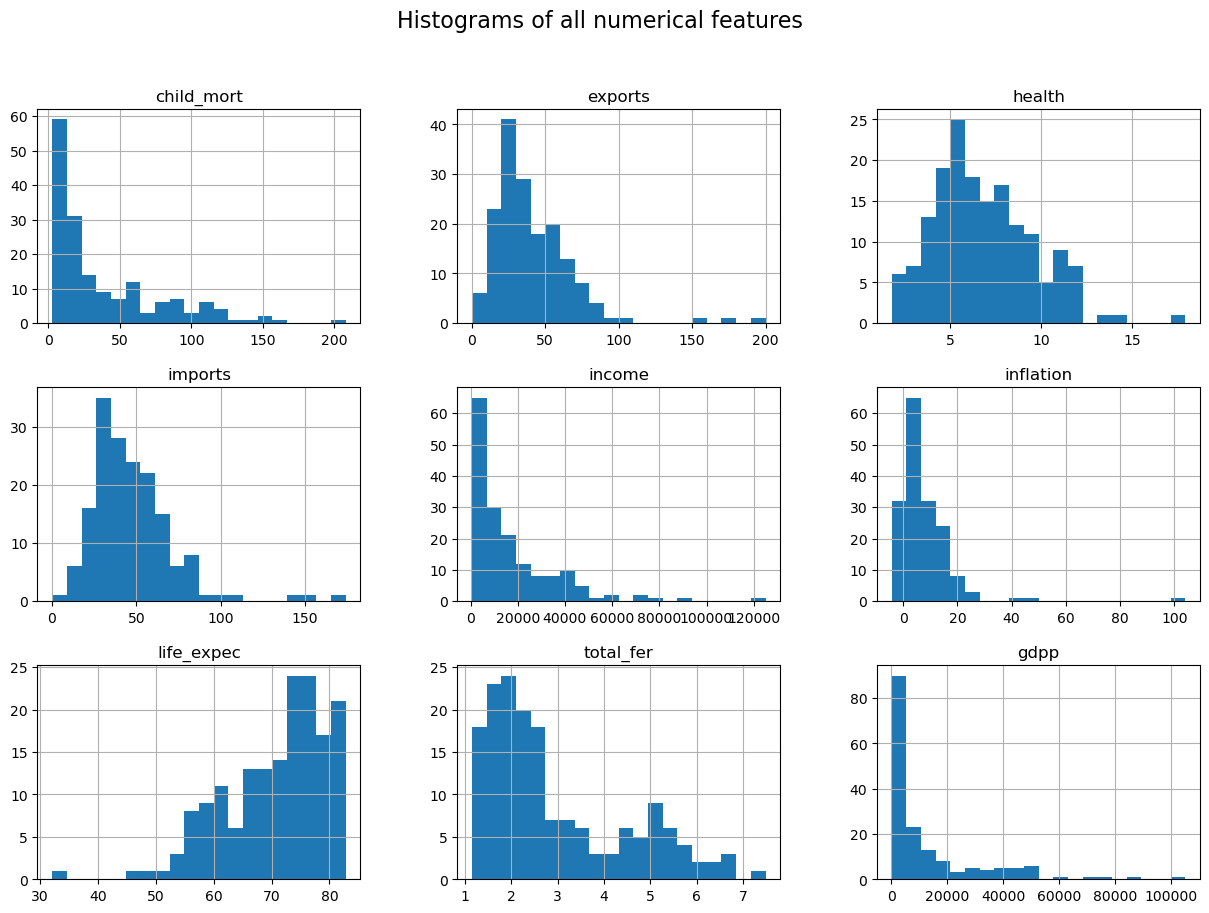

In [25]:
df.hist(figsize=(15,10), bins=20)
plt.suptitle('Histograms of all numerical features', fontsize=16)
plt.show()

# 📌 Boxplot

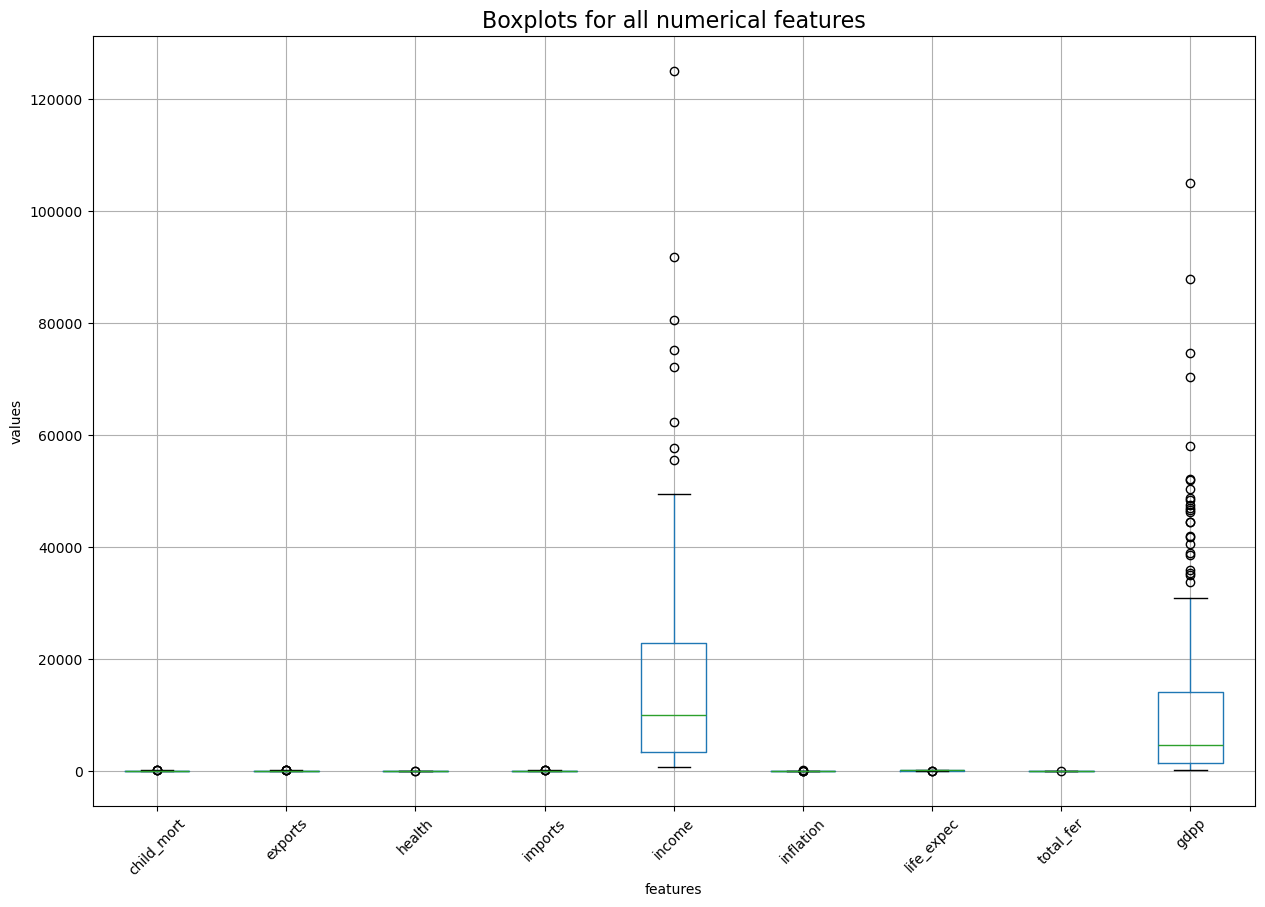

In [31]:
plt.figure(figsize=(15, 10))
df.boxplot(rot=45)
plt.title('Boxplots for all numerical features', fontsize=16)
plt.xlabel('features')
plt.ylabel('values')
plt.show()

## Observation: 
The boxplots reveal several outliers, particularly in income, gdpp, child_mort, and inflation. These outliers represent countries with significantly different socio-economic conditions. Since Hierarchical Clustering is a distance-based algorithm, feature scaling is essential to ensure that no single feature dominates the clustering process.

## 📌 Correlation Heatmap

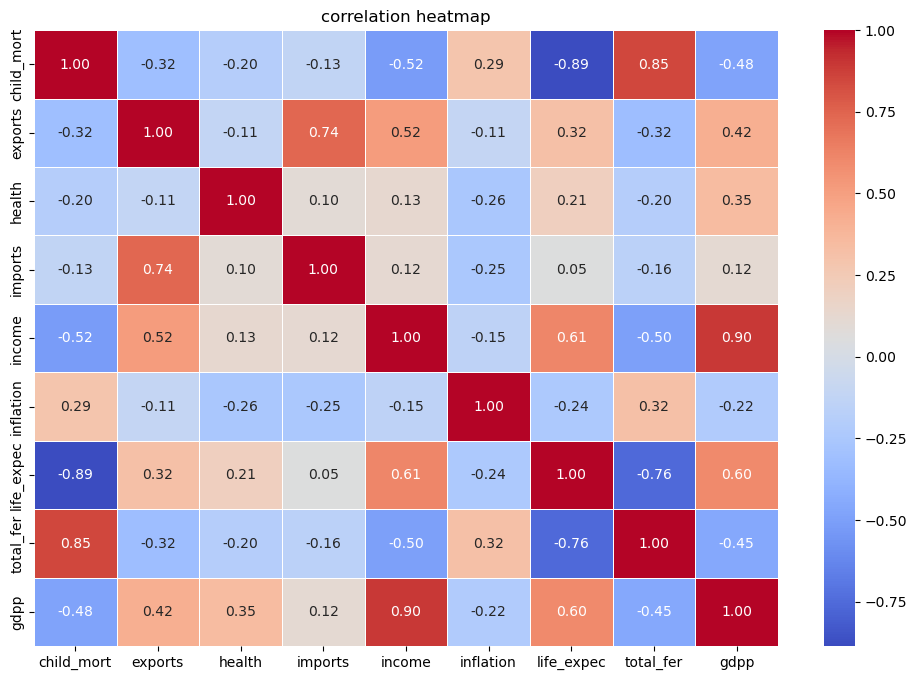

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('correlation heatmap')
plt.show()

## Observations:

Income and GDP per capita have a strong positive correlation (0.90), indicating that wealthier countries generally have higher GDP per capita.
Child mortality and total fertility show a strong positive correlation (0.85), suggesting that countries with higher birth rates often experience higher child mortality.
Child mortality and life expectancy have a strong negative correlation (-0.89), meaning countries with high child mortality usually have lower life expectancy.
Exports and imports are strongly positively correlated (0.74), reflecting active international trade.
Most other feature pairs have weak to moderate correlations, indicating that each feature contributes unique information for clustering.

# Step 5: Data Preprocessing

In [36]:
#scaling the data.
#first drop the country column because it is not a numerical feature and we cannot scale it.
X = df.drop('country', axis = 1)

In [37]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

In [38]:
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

In [39]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# 🚀 Step 6: Build the Dendrogram

In [ ]:
from scipy.cluster.hierarchy import dendrogram , linkage
linked = linkage(X_scaled, method='ward')


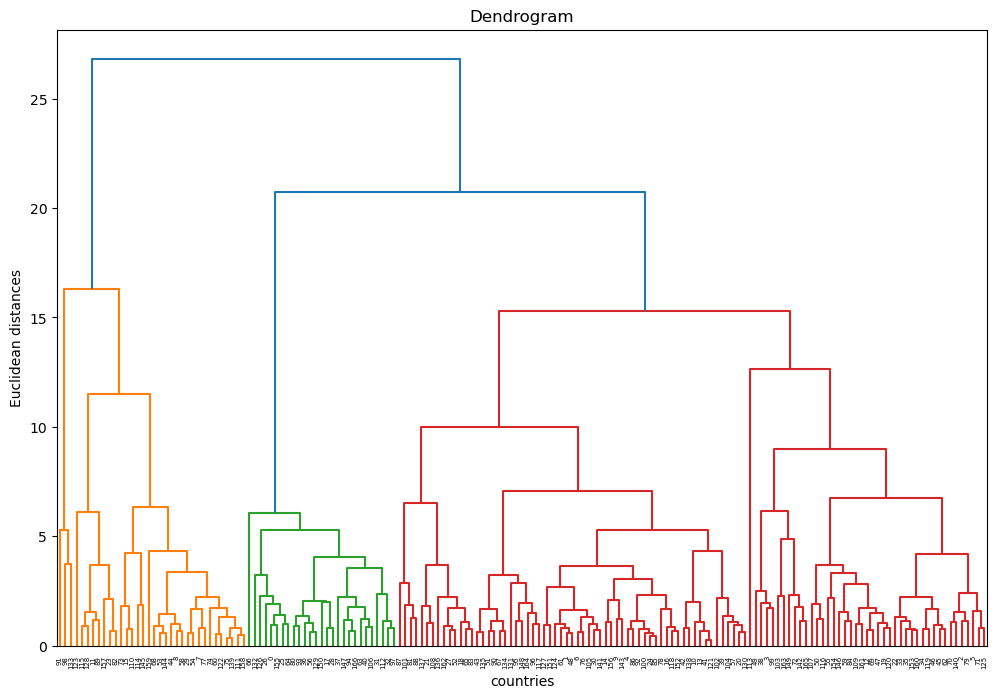

In [42]:
plt.figure(figsize=(12, 8))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('countries')
plt.ylabel('Euclidean distances')
plt.show()

# 📌 Step 6: Hierarchical Clustering - Dendrogram

## 🎯 Objective

The dendrogram helps visualize how observations (countries) are merged into clusters based on their similarity. It is used to determine the optimal number of clusters before applying Agglomerative Hierarchical Clustering.

---

## 📖 What is a Dendrogram?

A **dendrogram** is a tree-like diagram that illustrates the hierarchical relationship between data points. Initially, each country starts as an individual cluster. The algorithm then repeatedly merges the two most similar clusters until all countries belong to one final cluster.

The dendrogram records every merge and the distance at which it occurs.

---

## 📊 Understanding the Axes

### X-axis
- Represents the individual countries (observations).

### Y-axis
- Represents the Euclidean distance (dissimilarity) at which clusters are merged.

- Lower height → More similar clusters
- Higher height → Less similar clusters

---

## 🌳 How to Read a Dendrogram

- Read the dendrogram from **bottom to top**.
- Each country starts as an individual cluster.
- The algorithm merges the closest clusters first.
- As we move upward, clusters become larger.
- The final merge combines all observations into one cluster.

---

## ⚙️ What is Ward Linkage?

Ward linkage is a linkage criterion that merges the two clusters resulting in the **smallest increase in within-cluster variance**.

### Advantages
- Produces compact clusters
- Minimizes variance within clusters
- Works well with Euclidean distance
- Most commonly used linkage method in machine learning projects

---

## 📏 Why is Feature Scaling Required?

Hierarchical Clustering is a **distance-based algorithm**.

Features such as **GDP per capita** and **Income** have much larger numerical values than features like **Health** or **Inflation**.

Without scaling, large-valued features dominate the distance calculation.

Therefore, **StandardScaler** is applied before clustering so that every feature contributes equally.

---

## 🎯 Choosing the Optimal Number of Clusters

The dendrogram helps determine the number of clusters by identifying the **largest vertical gap** between successive merges.

Steps:
1. Draw a horizontal line across the dendrogram.
2. Choose the largest vertical distance where no merges occur.
3. Count the number of branches intersected by the horizontal line.
4. That count represents the optimal number of clusters.

---

## 📌 Observation

The dendrogram shows a noticeable increase in linkage distance before the final merges. Drawing a horizontal cut around the largest vertical gap results in **3 clusters**, indicating that the countries can be naturally grouped into three distinct categories.

---

## 💼 Business Insight

Hierarchical Clustering groups countries with similar socio-economic characteristics.

The resulting clusters can later be interpreted as:

- Cluster 0 → Developed Countries
- Cluster 1 → Developing Countries
- Cluster 2 → Underdeveloped Countries

These clusters can help governments and international organizations identify countries with similar development patterns and design targeted economic and social policies.

# 📌 Step 7: Build the Agglomerative Hierarchical Clustering Model

## 🎯 Objective

After determining the optimal number of clusters from the dendrogram, the next step is to train the Agglomerative Hierarchical Clustering model.

The model groups countries with similar socio-economic characteristics into distinct clusters based on Euclidean distance.

---

## 📖 What is Agglomerative Hierarchical Clustering?

Agglomerative Clustering is a **bottom-up hierarchical clustering algorithm**.

Initially, every country is treated as an individual cluster.

The algorithm repeatedly performs the following steps:

1. Find the two most similar clusters.
2. Merge them into one cluster.
3. Repeat until the desired number of clusters is reached.

Unlike K-Means, Agglomerative Clustering does **not require random initialization of centroids**.

---

## ⚙️ Model Parameters

### n_clusters
The number of clusters obtained from the dendrogram.

### metric='euclidean'
Uses Euclidean distance to measure similarity between observations.

### linkage='ward'
Ward linkage merges clusters that produce the smallest increase in within-cluster variance, resulting in compact and well-separated clusters.

---

## 📌 Expected Outcome

The trained model assigns a cluster label to every country.

Each country will belong to one of the identified development groups, which can later be analyzed and interpreted using their socio-economic indicators.

In [43]:
from sklearn.cluster import AgglomerativeClustering

In [44]:
model = AgglomerativeClustering(n_clusters=3, metric = 'euclidean', linkage = 'ward')

In [46]:
clusters = model.fit_predict(X_scaled)

In [47]:
clusters

array([2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1,
       1, 0, 1, 2, 2, 1, 2, 0, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 0, 1, 0, 1, 1, 2, 2, 1,
       2, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       0, 0, 2, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 0, 2, 1, 1,
       2, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2])

In [48]:
df['clusters'] = clusters

In [49]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusters
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [50]:
df['clusters'].value_counts().sort_index()

clusters
0     34
1    106
2     27
Name: count, dtype: int64

# Step 8: Cluster Analysis

In [52]:
cluster_summary = df.groupby('clusters').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
clusters,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


# Cluster 0
Income = High
GDP = High
Life Expectancy = High
Child Mortality = Low
Business Interpretation

This cluster represents developed countries with strong economies, high living standards, and good healthcare systems.

# Cluster 1
Income = Medium
GDP = Medium
Life Expectancy = Medium
Business Interpretation

This cluster represents developing countries with growing economies but room for improvement in healthcare and infrastructure.

# Cluster 2
Income = Low
GDP = Low
Life Expectancy = Low
Child Mortality = High
Business Interpretation

This cluster represents underdeveloped or low-income countries that may require greater investment in healthcare, education, and economic development.

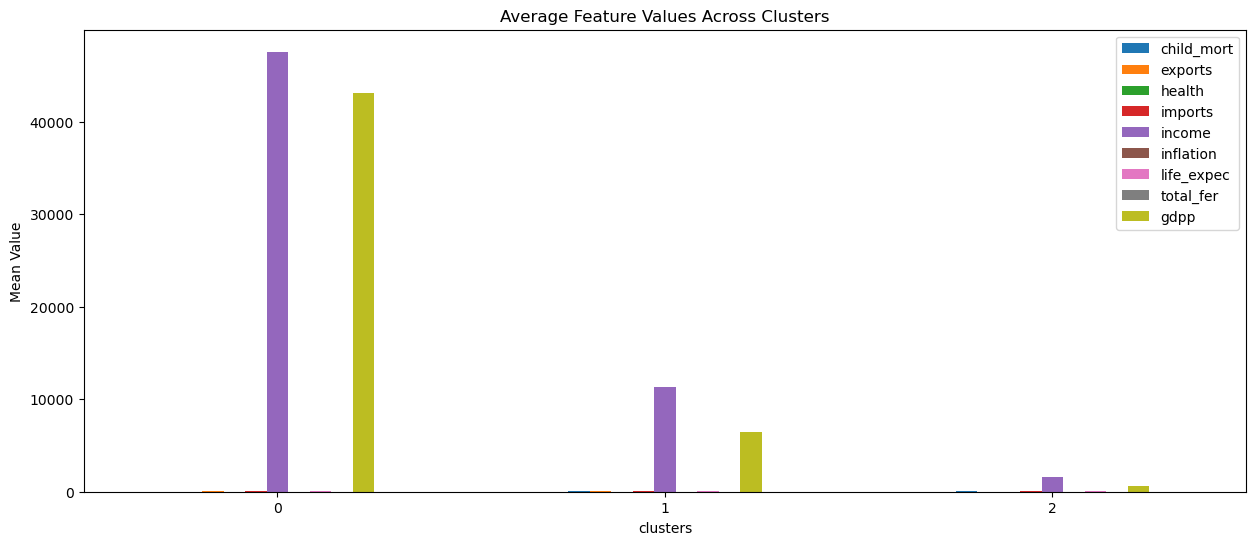

In [53]:
#Visualize the Cluster Means
cluster_summary.plot(kind='bar', figsize=(15,6))

plt.title("Average Feature Values Across Clusters")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.show()

# find Countries in Each Cluster

In [ ]:
#developed countries
df[df['clusters'] == 0]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusters
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,0
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,0
11,Bahrain,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700,0
15,Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,0
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,0
29,Canada,5.6,29.1,11.30,31.0,40700,2.870,81.3,1.63,47400,0
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000,0
53,Finland,3.0,38.7,8.95,37.4,39800,0.351,80.0,1.87,46200,0
54,France,4.2,26.8,11.90,28.1,36900,1.050,81.4,2.03,40600,0
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800,0


In [56]:
##developing countries
df[df['clusters'] == 1]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusters
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1
5,Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300,1
...,...,...,...,...,...,...,...,...,...,...,...
161,Uzbekistan,36.3,31.7,5.81,28.5,4240,16.50,68.8,2.34,1380,1
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,1
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,1
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,1


In [57]:
##underdeveloped or low-income countries
df[df['clusters'] == 2]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,clusters
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
17,Benin,111.0,23.80,4.10,37.2,1820,0.885,61.8,5.36,758,2
25,Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,2
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,2
28,Cameroon,108.0,22.20,5.13,27.0,2660,1.910,57.3,5.11,1310,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,2
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,2
36,Comoros,88.2,16.50,4.51,51.7,1410,3.870,65.9,4.75,769,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,2
40,Cote d'Ivoire,111.0,50.60,5.30,43.3,2690,5.390,56.3,5.27,1220,2


In [59]:
cluster_summary = df.groupby('clusters').mean(numeric_only=True)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
clusters,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


# 📌 Step 8.1: Cluster Analysis and Interpretation

## 🎯 Objective

After applying Agglomerative Hierarchical Clustering, each country has been assigned to a cluster. To understand the characteristics of each cluster, the average value of every numerical feature was calculated using the `groupby()` function.

This analysis helps identify the socio-economic profile of each cluster.

---

## 📊 Cluster Summary

### 🔹 Cluster 0 – Developed Countries

**Characteristics:**
- Highest Average Income (~47,588)
- Highest GDP per Capita (~43,171)
- Highest Life Expectancy (~80 years)
- Lowest Child Mortality (~6)
- Lowest Fertility Rate (~1.89)
- Highest Health Expenditure

**Interpretation:**

This cluster represents **developed countries** with strong economies, excellent healthcare systems, high living standards, and low child mortality. These countries are economically stable and highly developed.

---

### 🔹 Cluster 1 – Developing Countries

**Characteristics:**
- Moderate Income (~11,342)
- Moderate GDP per Capita (~6,407)
- Moderate Life Expectancy (~71 years)
- Moderate Child Mortality (~32)
- Moderate Fertility Rate (~2.65)

**Interpretation:**

This cluster represents **developing countries**. These nations have growing economies and improving healthcare systems but still face challenges in reducing child mortality and increasing income levels.

---

### 🔹 Cluster 2 – Underdeveloped Countries

**Characteristics:**
- Lowest Income (~1,590)
- Lowest GDP per Capita (~668)
- Lowest Life Expectancy (~57 years)
- Highest Child Mortality (~105)
- Highest Fertility Rate (~5.43)

**Interpretation:**

This cluster represents **underdeveloped countries** with limited economic resources, poor healthcare infrastructure, high child mortality, and low life expectancy. These countries require greater investment in healthcare, education, and economic development.

---

# 📈 Overall Observations

- **Cluster 0** contains economically advanced countries with high GDP, high income, and excellent healthcare indicators.
- **Cluster 1** represents countries in transition with moderate socio-economic development.
- **Cluster 2** consists of countries with low income, poor healthcare, high fertility, and high child mortality.

The clustering results clearly separate countries into different development levels based on their socio-economic indicators.

---

# 💼 Business Insight

Governments, policymakers, and international organizations can use these clusters to:

- Identify countries requiring financial or humanitarian assistance.
- Develop targeted healthcare and education policies.
- Compare countries with similar socio-economic conditions.
- Allocate development funds more effectively.
- Support evidence-based decision-making for sustainable development.

---

# ✅ Conclusion

Agglomerative Hierarchical Clustering successfully grouped countries into three meaningful clusters based on socio-economic characteristics. The resulting clusters correspond to **Developed**, **Developing**, and **Underdeveloped** countries, demonstrating that hierarchical clustering is an effective technique for country segmentation and policy planning.